# Hotel Booking Analytics Pipeline:
## Data Engineering and Machine Learning Project

## Project Overview

The hospitality industry generates large volumes of booking data every day. Analyzing this data helps hotels understand customer behavior, booking trends, cancellation patterns, and revenue performance. Effective data engineering practices enable organizations to transform raw booking records into meaningful business insights.

This project demonstrates an end-to-end Data Engineering workflow using the Hotel Booking Demand dataset. The project covers data ingestion, cleaning, SQL-based analysis, ETL pipeline development, PySpark Medallion Architecture implementation, data visualization, and machine learning. The goal is to convert raw hotel booking data into business-ready datasets and actionable insights that support data-driven decision-making.

## Objectives

The primary objectives of this project are:

1. To ingest and analyze the Hotel Booking Demand dataset using Pandas.
2. To perform data cleaning and preprocessing by handling missing values, duplicates, and data inconsistencies.
3. To store and manage the cleaned dataset using SQLite.
4. To perform SQL-based analytical queries for extracting business insights.
5. To implement SQL-based data transformations and create derived business attributes.
6. To design and implement a complete ETL (Extract, Transform, Load) pipeline.
7. To build a three-layer Medallion Architecture (Bronze, Silver, and Gold) using PySpark.
8. To compare CSV and Parquet file formats in terms of storage efficiency and performance.
9. To convert Parquet data back into Pandas DataFrames for validation.
10. To create meaningful visualizations that highlight booking trends and customer behavior.
11. To develop a Machine Learning model for predicting hotel booking cancellations.
12. To demonstrate an end-to-end Data Engineering workflow following industry best practices.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import os
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [2]:
df = pd.read_csv("hotel_bookings.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


/tmp/ipykernel_17077/615662924.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hotel_bookings.csv")


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


## Dataset Overview

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Shape: (58890, 32)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
sta

## Basic Statistics

In [4]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,58890,58890.000000,58890.000000,58890.000000,58890,58890.000000,58890.000000,58890.000000,58890.000000,58890.000000,...,58890,49758.000000,3479.0,58889.000000,58889,58889.000000,58889.000000,58889.000000,58889,58889
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,277.0,NaN,4,NaN,NaN,NaN,3,921
top,Resort Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,223.0,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,40060,NaN,NaN,NaN,7714,NaN,NaN,NaN,NaN,NaN,...,52328,NaN,784.0,NaN,42848,NaN,NaN,NaN,34665,971
mean,NaN,0.411360,100.046714,2015.974597,NaN,27.837426,15.767159,1.058142,2.847631,1.860740,...,NaN,146.981310,NaN,3.526278,NaN,96.251314,0.096690,0.512184,NaN,NaN
std,NaN,0.492084,101.157752,0.687274,NaN,13.346370,8.783033,1.093056,2.235539,0.634778,...,NaN,120.113863,NaN,21.842580,NaN,58.557048,0.300326,0.768375,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,NaN,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,17.000000,2016.000000,NaN,17.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,NaN,0.000000,NaN,60.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,29.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,196.000000,NaN,0.000000,NaN,84.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,157.000000,2016.000000,NaN,38.000000,23.000000,2.000000,4.000000,2.000000,...,NaN,240.000000,NaN,0.000000,NaN,120.000000,0.000000,1.000000,NaN,NaN


## Data Cleaning

In [5]:
df_clean = df.copy()

# Handle Missing Values

df_clean["children"] = df_clean["children"].fillna(
    df_clean["children"].median()
)

df_clean["country"] = df_clean["country"].fillna(
    df_clean["country"].mode()[0]
)

df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

print("Missing values handled.")

Missing values handled.


## Remove Duplicates

In [6]:
before = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after = df_clean.shape[0]

print("Rows Before:", before)
print("Rows After :", after)
print("Duplicates Removed:", before-after)

Rows Before: 58890
Rows After : 44184
Duplicates Removed: 14706


## Correct Data Types

In [7]:
# Convert dates safely

df_clean["reservation_status_date"] = pd.to_datetime(
    df_clean["reservation_status_date"],
    errors="coerce"
)

# Count invalid dates
print(
    "Invalid dates:",
    df_clean["reservation_status_date"].isna().sum()
)

# Fill missing dates with most frequent date
most_common_date = df_clean["reservation_status_date"].mode()[0]

df_clean["reservation_status_date"] = (
    df_clean["reservation_status_date"]
    .fillna(most_common_date)
)

# Children column
df_clean["children"] = (
    df_clean["children"]
    .fillna(0)
    .astype(int)
)

df_clean.info()



Invalid dates: 1
<class 'pandas.core.frame.DataFrame'>
Index: 44184 entries, 0 to 58889
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           44184 non-null  object        
 1   is_canceled                     44184 non-null  int64         
 2   lead_time                       44184 non-null  int64         
 3   arrival_date_year               44184 non-null  int64         
 4   arrival_date_month              44184 non-null  object        
 5   arrival_date_week_number        44184 non-null  int64         
 6   arrival_date_day_of_month       44184 non-null  int64         
 7   stays_in_weekend_nights         44184 non-null  int64         
 8   stays_in_week_nights            44184 non-null  int64         
 9   adults                          44184 non-null  int64         
 10  children                        44184 non-null  int64     

## Rename Columns

In [8]:
df_clean.rename(columns={
    "is_canceled":"booking_canceled",
    "adr":"average_daily_rate"
}, inplace=True)

df_clean.head()

,hotel,booking_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


In [9]:
df_clean.to_csv("hotel_bookings_cleaned.csv", index=False)   # save cleaned dataset
print("Cleaned Dataset Saved")

Cleaned Dataset Saved


## SQLite Database Creation

In [10]:
conn = sqlite3.connect("hotel_bookings.db")
df_clean.to_sql(
    "hotel_bookings",
    conn,
    if_exists="replace",
    index=False
)

print("Data Loaded into SQLite")

Data Loaded into SQLite


In [11]:
# Total Record Count
query = """
SELECT COUNT(*) as total_records
FROM hotel_bookings
"""
pd.read_sql(query, conn)

,total_records
0,44184


In [12]:
# filters bookings having lead time greater than 200 days
query = """
SELECT hotel, lead_time
FROM hotel_bookings
WHERE lead_time > 200
LIMIT 10
"""

pd.read_sql(query, conn)

,hotel,lead_time
0,Resort Hotel,342
1,Resort Hotel,737
2,Resort Hotel,368
3,Resort Hotel,364
4,Resort Hotel,324
5,Resort Hotel,258
6,Resort Hotel,292
7,Resort Hotel,280
8,Resort Hotel,394
9,Resort Hotel,366


In [13]:
# Displays highest ADR bookings sorted in descending order.
query = """
SELECT hotel, lead_time
FROM hotel_bookings
WHERE lead_time > 200
LIMIT 10
"""

pd.read_sql(query, conn)

,hotel,lead_time
0,Resort Hotel,342
1,Resort Hotel,737
2,Resort Hotel,368
3,Resort Hotel,364
4,Resort Hotel,324
5,Resort Hotel,258
6,Resort Hotel,292
7,Resort Hotel,280
8,Resort Hotel,394
9,Resort Hotel,366


In [14]:
query = """
SELECT hotel, average_daily_rate
FROM hotel_bookings
ORDER BY average_daily_rate DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,hotel,average_daily_rate
0,City Hotel,5400.00
1,Resort Hotel,508.00
2,Resort Hotel,450.00
3,Resort Hotel,437.00
4,Resort Hotel,426.25
5,Resort Hotel,402.00
6,Resort Hotel,397.38
7,Resort Hotel,392.00
8,Resort Hotel,392.00
9,Resort Hotel,388.00


In [15]:
query = """
SELECT
AVG(average_daily_rate) as avg_rate,
MAX(average_daily_rate) as max_rate,
MIN(average_daily_rate) as min_rate
FROM hotel_bookings
"""

pd.read_sql(query, conn)

,avg_rate,max_rate,min_rate
0,100.306957,5400.0,-6.38


In [16]:
query = """
SELECT hotel,
COUNT(*) as total_bookings
FROM hotel_bookings
GROUP BY hotel
"""

pd.read_sql(query, conn)

,hotel,total_bookings
0,City Hotel,10235
1,Resort Hotel,33949


In [17]:
query = """
SELECT hotel,
COUNT(*) as canceled_bookings
FROM hotel_bookings
WHERE booking_canceled = 1
GROUP BY hotel
"""

pd.read_sql(query, conn)

,hotel,canceled_bookings
0,City Hotel,6531
1,Resort Hotel,7975


In [18]:
query = """
SELECT *,

CASE
WHEN booking_canceled=1
THEN 'Canceled'
ELSE 'Not Canceled'
END AS booking_status,

CASE
WHEN average_daily_rate > 150
THEN 'Premium'
WHEN average_daily_rate > 75
THEN 'Standard'
ELSE 'Budget'
END AS price_category

FROM hotel_bookings
"""

transformed_df = pd.read_sql(query, conn)

transformed_df.head()

,hotel,booking_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,booking_status,price_category
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01 00:00:00,Not Canceled,Budget
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01 00:00:00,Not Canceled,Budget
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02 00:00:00,Not Canceled,Budget
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02 00:00:00,Not Canceled,Budget
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03 00:00:00,Not Canceled,Standard


In [19]:
transformed_df.to_csv(
    "hotel_bookings_transformed.csv",
    index=False
)

print("Transformed Dataset Exported")

Transformed Dataset Exported


## ETL Pipeline

In [20]:
def extract(path):
    return pd.read_csv(path)

def transform(df):

    df["children"] = df["children"].fillna(
        df["children"].median()
    )

    df["country"] = df["country"].fillna(
        df["country"].mode()[0]
    )

    df["agent"] = df["agent"].fillna(0)
    df["company"] = df["company"].fillna(0)

    df = df.drop_duplicates()

    return df

def load(df, output):
    df.to_csv(output, index=False)

data = extract("hotel_bookings.csv")

data = transform(data)

load(data, "etl_output.csv")

print("ETL Completed")

ETL Completed


## Install PySpark

In [21]:
!pip install pyspark -q

In [22]:
# start spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HotelBookingProject") \
    .getOrCreate()

In [23]:
# Bronze Layer
bronze_df = spark.read.csv(
    "hotel_bookings.csv",
    header=True,
    inferSchema=True
)

bronze_df.write.mode("overwrite").parquet(
    "bronze_layer"
)

print("Bronze Layer Created")

Bronze Layer Created


In [24]:
# Silver Layer
silver_df = bronze_df.dropDuplicates()

silver_df = silver_df.fillna({
    "agent":0,
    "company":0
})

silver_df.write.mode("overwrite").parquet(
    "silver_layer"
)

print("Silver Layer Created")

Silver Layer Created


In [25]:
# Gold Layer
from pyspark.sql.functions import count

gold_df = silver_df.groupBy(
    "hotel"
).agg(
    count("*").alias("total_bookings")
)

gold_df.show()

gold_df.write.mode("overwrite").parquet(
    "gold_layer"
)

print("Gold Layer Created")

+------------+--------------+
|       hotel|total_bookings|
+------------+--------------+
|  City Hotel|         53428|
|Resort Hotel|         33968|
+------------+--------------+

Gold Layer Created


In [26]:
# CSV vs Parquet Comparison
df_clean.to_csv("comparison.csv", index=False)

silver_df.write.mode("overwrite").parquet(
    "comparison_parquet"
)

In [27]:
# Compare File Size
csv_size = os.path.getsize("comparison.csv")
import os

parquet_size = 0

for root, dirs, files in os.walk("comparison_parquet"):
    for f in files:
        parquet_size += os.path.getsize(
            os.path.join(root,f)
        )

comparison = pd.DataFrame({
    "Metric":[
        "File Size (Bytes)"
    ],
    "CSV":[csv_size],
    "Parquet":[parquet_size]
})

comparison

,Metric,CSV,Parquet
0,File Size (Bytes),6549029,1239835


In [28]:
# Comparison Table
comparison_table = pd.DataFrame({
"Dimension":[
"File Size",
"Storage Efficiency",
"Read Performance",
"Write Performance",
"Advantages",
"Limitations"
],

"CSV":[
"Larger",
"Low",
"Moderate",
"Fast",
"Human Readable",
"No Compression"
],

"Parquet":[
"Smaller",
"High",
"Very Fast",
"Fast",
"Compressed & Columnar",
"Not Human Readable"
]
})

comparison_table

,Dimension,CSV,Parquet
0,File Size,Larger,Smaller
1,Storage Efficiency,Low,High
2,Read Performance,Moderate,Very Fast
3,Write Performance,Fast,Fast
4,Advantages,Human Readable,Compressed & Columnar
5,Limitations,No Compression,Not Human Readable


In [29]:
# Read Parquet
parquet_df = spark.read.parquet(
    "silver_layer"
)

parquet_df.show(5)

+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+-------------+------+---------------------------+-------------------------+------------------+-----------------------+
|       hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type|   adr|required_car_parking_spaces|to

In [30]:
# Convert Parquet to Pandas
pandas_df = parquet_df.toPandas()

print(type(pandas_df))

pandas_df.head()

<class 'pandas.core.frame.DataFrame'>


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,NULL,110,0,Transient,107.42,0,0,Check-Out,2015-07-02
1,Resort Hotel,0,80,2015,July,28,6,3,8,1,...,No Deposit,NULL,NULL,0,Transient,73.00,0,0,Check-Out,2015-07-17
2,Resort Hotel,1,105,2015,July,28,8,0,4,2,...,No Deposit,240,NULL,0,Transient,73.80,0,1,Canceled,2015-06-29
3,Resort Hotel,0,34,2015,July,28,10,2,5,2,...,No Deposit,241,NULL,0,Transient,95.27,0,3,Check-Out,2015-07-17
4,Resort Hotel,0,27,2015,July,31,27,1,3,2,...,No Deposit,240,NULL,0,Transient,153.00,0,0,Check-Out,2015-07-31


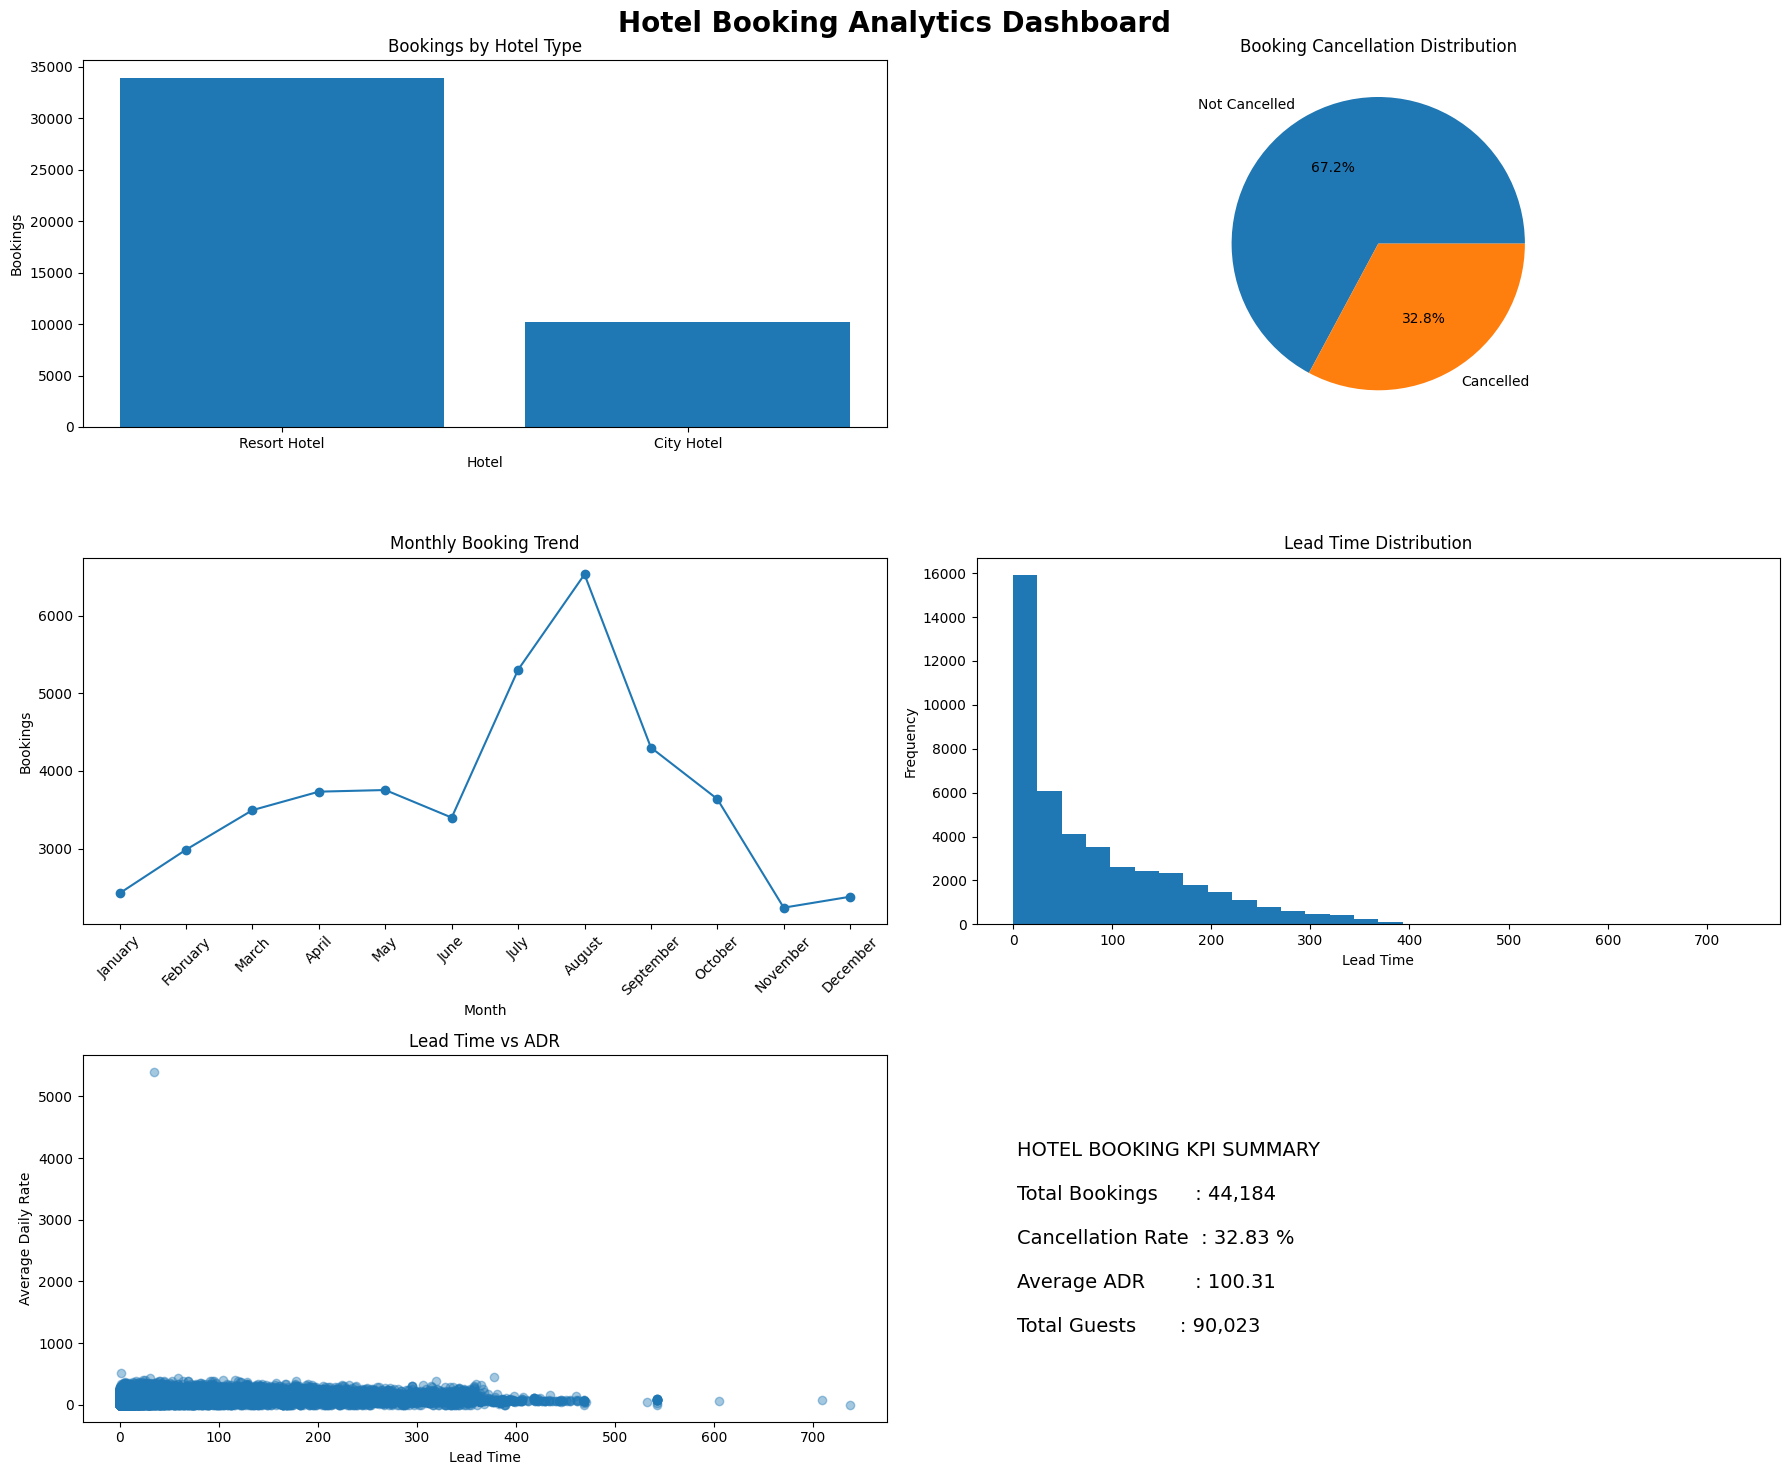

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure correct column names
if 'is_canceled' in df_clean.columns:
    cancel_col = 'is_canceled'
else:
    cancel_col = 'booking_canceled'

if 'adr' in df_clean.columns:
    adr_col = 'adr'
else:
    adr_col = 'average_daily_rate'

# Month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

# Create dashboard
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle(
    'Hotel Booking Analytics Dashboard',
    fontsize=20,
    fontweight='bold'
)

# 1. BAR CHART
hotel_counts = df_clean['hotel'].value_counts()

axes[0,0].bar(
    hotel_counts.index,
    hotel_counts.values
)

axes[0,0].set_title('Bookings by Hotel Type')
axes[0,0].set_xlabel('Hotel')
axes[0,0].set_ylabel('Bookings')

# 2. PIE CHART

cancel_counts = df_clean[cancel_col].value_counts()

axes[0,1].pie(
    cancel_counts,
    labels=['Not Cancelled','Cancelled'],
    autopct='%1.1f%%'
)

axes[0,1].set_title('Booking Cancellation Distribution')

# 3. LINE CHART

monthly_bookings = (
    df_clean.groupby('arrival_date_month')
    .size()
    .reindex(month_order)
)

axes[1,0].plot(
    monthly_bookings.index,
    monthly_bookings.values,
    marker='o'
)

axes[1,0].set_title('Monthly Booking Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Bookings')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. HISTOGRAM
axes[1,1].hist(
    df_clean['lead_time'],
    bins=30
)

axes[1,1].set_title('Lead Time Distribution')
axes[1,1].set_xlabel('Lead Time')
axes[1,1].set_ylabel('Frequency')

# 5. SCATTER PLOT

axes[2,0].scatter(
    df_clean['lead_time'],
    df_clean[adr_col],
    alpha=0.4
)

axes[2,0].set_title('Lead Time vs ADR')
axes[2,0].set_xlabel('Lead Time')
axes[2,0].set_ylabel('Average Daily Rate')

# KPI SUMMARY

total_bookings = len(df_clean)

cancel_rate = round(
    df_clean[cancel_col].mean()*100,
    2
)

avg_adr = round(
    df_clean[adr_col].mean(),
    2
)

total_guests = (
    df_clean['adults'].sum() +
    df_clean['children'].sum() +
    df_clean['babies'].sum()
)

axes[2,1].axis('off')

summary_text = f"""
HOTEL BOOKING KPI SUMMARY

Total Bookings      : {total_bookings:,}

Cancellation Rate  : {cancel_rate} %

Average ADR        : {avg_adr}

Total Guests       : {total_guests:,}
"""

axes[2,1].text(
    0.05,
    0.5,
    summary_text,
    fontsize=14,
    verticalalignment='center'
)

plt.tight_layout()
plt.show()

In [32]:
ml_df = transformed_df.copy()

## Machine Learning

In [33]:
# Encode Categorical Columns
le = LabelEncoder()

for col in ml_df.select_dtypes(
    include="object"
).columns:

    ml_df[col] = le.fit_transform(
        ml_df[col].astype(str)
    )

In [34]:
# Train Test Split
# Target
y = ml_df["booking_canceled"]

# Remove target and leakage columns
X = ml_df.drop(columns=[
    "booking_canceled",
    "reservation_status",
    "reservation_status_date",
    "booking_status"
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
# Predictions
y_pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.8961185922824488


In [37]:
# Evaluation Metrics
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      5917
           1       0.86      0.81      0.84      2920

    accuracy                           0.90      8837
   macro avg       0.89      0.88      0.88      8837
weighted avg       0.90      0.90      0.90      8837



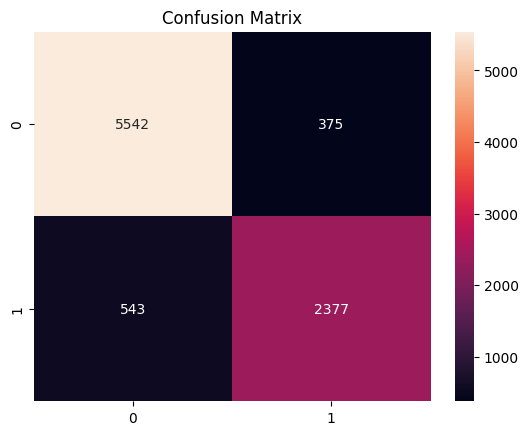

In [38]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [39]:
print(X.columns.tolist())

['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'average_daily_rate', 'required_car_parking_spaces', 'total_of_special_requests', 'price_category']


--END-OF-PHASE1-CAPSTONE-PROJECT-